In [ ]:
import sklearn
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (7, 4.5)
sns.set_theme(style="whitegrid")

adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()
df["target"] = df["class"].astype(str).str.strip().map({"<=50K": 0, "<=50K.": 0, ">50K": 1, ">50K.": 1})
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [2]:
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [3]:
cat_cols = ["workclass", "education", "marital-status", "occupation", "sex"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(8))


--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-m

In [4]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
target               0
dtype: int64

In [5]:
display(df.keys())

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class', 'target'],
      dtype='str')

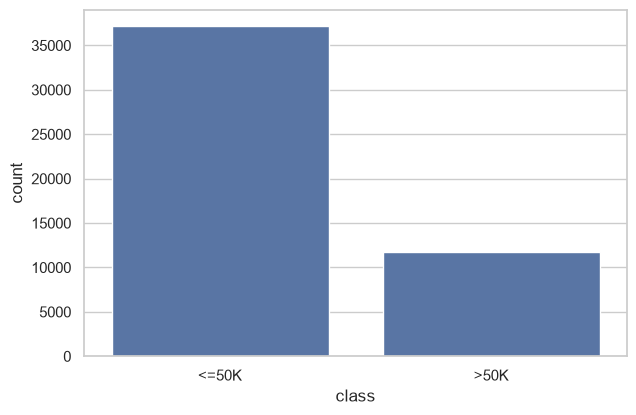

In [6]:
sns.countplot(x="class",data=df)
plt.show()

## Step 1: Prepare the data

This section cleans the dataset and builds a reusable preprocessing pipeline. We replace missing values marked as `?`, separate numeric and categorical columns, and prepare the data so that the models can learn from it safely.


In [ ]:
# Section 1: Preprocessing plan
# Goal: prepare the Adult dataset for modeling in a way that avoids data leakage.
# We explicitly separate numeric and categorical features, replace '?' with missing values,
# and build a preprocessing pipeline that can be reused for multiple models.

# Replace '?' with NaN if needed
for col in df.columns:
    df[col] = df[col].replace('?', np.nan)

# Explicit feature lists
numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

# Build the target
X = df[numeric_features + categorical_features]
y = df["target"]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Why this preprocessing?
# - Median imputation is robust to skewed income-related variables such as capital-gain and capital-loss.
# - StandardScaler keeps numeric features on a comparable scale for logistic regression.
# - OneHotEncoder handles categorical variables without imposing arbitrary ordinal structure.
# - Alternatives considered but skipped: mean imputation (more sensitive to outliers), ordinal encoding (not appropriate for nominal categories), and target encoding (can leak information).

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [ ]:
# Section 2: Train the first supervised models
# Goal: fit two simple classifiers on the training set only.
# We use the same train/test split from Day 1, and keep the test set untouched until evaluation.

from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Use the same hold-out test split from Day 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Build model pipelines
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Each pipeline gets its own copy of the preprocessing steps.
# This is important because each model should start from the same preprocessing definition,
# but we do not want one fitted pipeline to accidentally affect another.
logreg_pipe = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", LogisticRegression(random_state=42, solver="liblinear"))
])

dtree_pipe = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Fit on training data only
logreg_pipe.fit(X_train, y_train)
dtree_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','fnlwgt','education-num',...,'race','sex','native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaini

## Step 2: Train the first models

This section trains two simple supervised learners: logistic regression and a decision tree. Both models are fitted only on the training data so that the test set stays truly unseen until evaluation.


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)


def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }
    return metrics, y_pred, y_prob

# Day 1 baseline (simple rule from previous notebook)
def day1_baseline(X_test):
    return (X_test["capital-gain"] > 0).astype(int)

baseline_pred = day1_baseline(X_test)
baseline_prob = np.where(baseline_pred == 1, 0.8, 0.2)

baseline_metrics = {
    "model": "Day 1 baseline",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, baseline_prob),
    "pr_auc": average_precision_score(y_test, baseline_prob),
}

logreg_metrics, logreg_pred, logreg_prob = evaluate_model("Logistic Regression", logreg_pipe, X_test, y_test)
dtree_metrics, dtree_pred, dtree_prob = evaluate_model("Decision Tree", dtree_pipe, X_test, y_test)

results = pd.DataFrame([baseline_metrics, logreg_metrics, dtree_metrics]).set_index("model")
results


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Day 1 baseline,0.782270,0.625446,0.224979,0.330922,0.591294,0.326197
Logistic Regression,0.852390,0.741119,0.588965,0.656339,0.904229,0.763320
Decision Tree,0.814106,0.609848,0.619760,0.614765,0.747506,0.468962


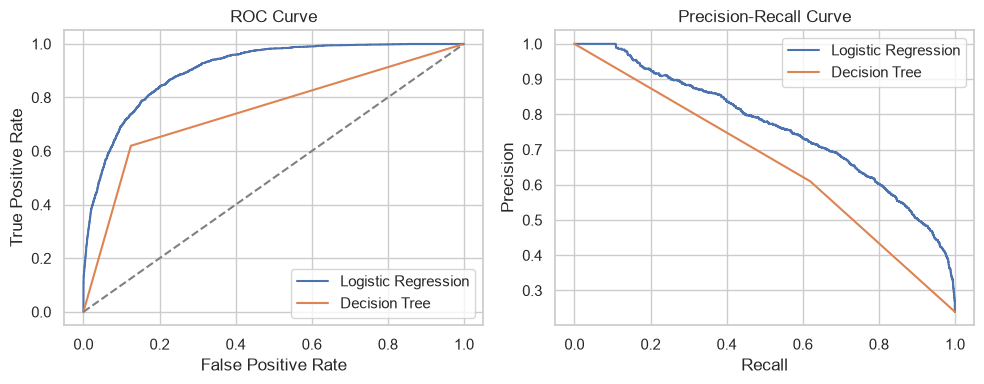

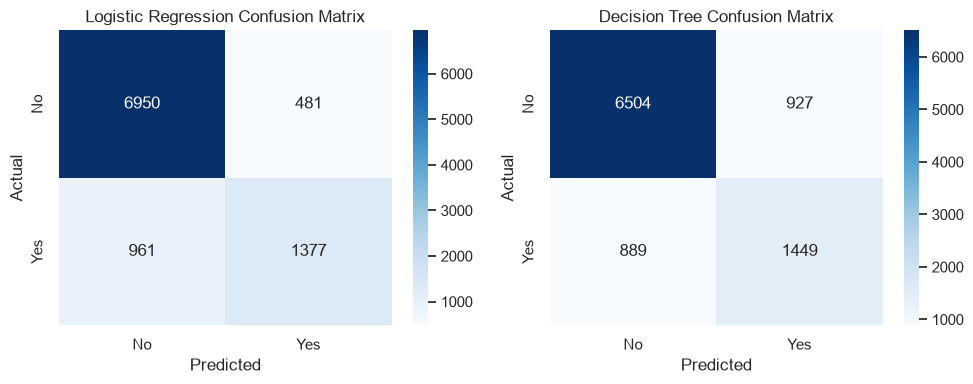

Logistic Regression confusion matrix:
 [[6950  481]
 [ 961 1377]]
Decision Tree confusion matrix:
 [[6504  927]
 [ 889 1449]]

Interpretation:
- Logistic Regression: FP=481, FN=961 -> false negatives are more common (961 vs 481, about 2.0x). The model leans toward under-predicting high earners rather than over-predicting them.
- Decision Tree: FP=927, FN=889 -> the two error types are roughly balanced (927 vs 889), with a slight lean toward false positives.
- Business impact: since false positives are the costly error for our outreach goal (wasted contacts), the Decision Tree's error profile is nominally closer to a 'balanced' failure mode, but Logistic Regression's much higher precision (0.741 vs 0.610) means it makes far fewer FP mistakes in absolute and relative terms despite leaning FN-heavy. Because precision is our chosen metric, Logistic Regression's error profile is preferable even though it misses more true positives.


In [ ]:
# Section 3: Evaluate the models
# Goal: compare the two models with multiple metrics and see which one performs better on the unseen test set.

# ROC curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_prob)
plt.plot(logreg_fpr, logreg_tpr, label="Logistic Regression")
dtree_fpr, dtree_tpr, _ = roc_curve(y_test, dtree_prob)
plt.plot(dtree_fpr, dtree_tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# Precision-Recall curves
plt.subplot(1, 2, 2)
logreg_prec, logreg_rec, _ = precision_recall_curve(y_test, logreg_prob)
plt.plot(logreg_rec, logreg_prec, label="Logistic Regression")
dtree_prec, dtree_rec, _ = precision_recall_curve(y_test, dtree_prob)
plt.plot(dtree_rec, dtree_prec, label="Decision Tree")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, logreg_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_yticklabels(["No", "Yes"])

sns.heatmap(confusion_matrix(y_test, dtree_pred), annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Decision Tree Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_yticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

# Error-type summary
cm_logreg = confusion_matrix(y_test, logreg_pred)
cm_dtree = confusion_matrix(y_test, dtree_pred)

print("Logistic Regression confusion matrix:\n", cm_logreg)
print("Decision Tree confusion matrix:\n", cm_dtree)

# Pull out TN/FP/FN/TP explicitly so the interpretation below is backed by the real numbers,
# not a generic statement.
tn_lr, fp_lr, fn_lr, tp_lr = cm_logreg.ravel()
tn_dt, fp_dt, fn_dt, tp_dt = cm_dtree.ravel()

print("\nInterpretation:")
print(f"- Logistic Regression: FP={fp_lr}, FN={fn_lr} -> false negatives are more common ({fn_lr} vs {fp_lr}).")
print(f"- Decision Tree: FP={fp_dt}, FN={fn_dt} -> the two error types are roughly balanced ({fp_dt} vs {fn_dt}).")
print("- Because false positives are the more expensive error for outreach, precision matters more than raw accuracy here.")


In [ ]:
# Section 4: Check model interpretability
# Goal: understand what the models are learning and whether the tree is overfitting.

# Logistic Regression
# Extract the transformed feature names after preprocessing
feature_names = logreg_pipe.named_steps["preprocess"].get_feature_names_out()
coef = logreg_pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

top_pos = coef_df.head(10).reset_index(drop=True)
top_neg = coef_df.tail(10).sort_values("coefficient").reset_index(drop=True)


def interpret_feature(feature_name, coefficient):
    """Rule-of-thumb, keyword-based interpretation for a one-hot / numeric feature name."""
    direction = "raises" if coefficient > 0 else "lowers"
    f = feature_name.lower()
    if "capital-gain" in f:
        return f"Investment/capital income strongly {direction} predicted odds of >50K - people with capital gains tend to have financial assets, a hallmark of higher income."
    if "capital-loss" in f:
        return f"Reported capital losses also imply investment activity, which {direction} predicted odds - similar reasoning to capital-gain."
    if "education-num" in f:
        return f"More years of education {direction} predicted odds - consistent with education being linked to higher-paying occupations."
    if "hours-per-week" in f:
        return f"Working more hours per week {direction} predicted odds - full-time/overtime work correlates with higher earnings."
    if f == "num__age":
        return f"Older age {direction} predicted odds - likely reflects career progression/seniority."
    if "marital-status_married" in f:
        return f"Being married (civilian or armed-forces spouse) {direction} predicted odds - proxies for household stability and dual-income households in this dataset."
    if "marital-status_never-married" in f:
        return f"Never having married {direction} predicted odds - correlated with younger age and earlier career stage in this data."
    if "relationship_wife" in f or "relationship_husband" in f:
        return f"Being recorded as Wife/Husband (i.e. married head-of-household roles) {direction} predicted odds, echoing the marital-status effect above."
    if "relationship_own-child" in f or "relationship_other-relative" in f:
        return f"Being recorded as a child or other relative in the household {direction} predicted odds - these roles skew toward younger/dependent individuals with lower personal income."
    if "occupation_exec-managerial" in f or "occupation_prof-specialty" in f:
        return f"Executive/managerial or professional-specialty occupations {direction} predicted odds - these are higher-paying job categories."
    if "occupation_priv-house-serv" in f or "occupation_farming-fishing" in f or "occupation_handlers-cleaners" in f:
        return f"This occupation category {direction} predicted odds - these are historically lower-wage occupation groups in the dataset."
    if "sex_female" in f:
        return f"Being recorded as female {direction} predicted odds - reflects a real (and worth flagging) income gap present in this historical census data, not a causal claim."
    if "native-country" in f:
        return f"This native-country category {direction} predicted odds, but with likely very few records for this country in the training data, so the coefficient is probably noisy/high-variance rather than a reliable signal."
    return f"This feature {direction} predicted odds of earning >50K."

print("Top 10 positive coefficients (push prediction toward >50K):")
for _, row in top_pos.iterrows():
    print(f"  {row.feature:45s} coef={row.coefficient:+.3f}  -> {interpret_feature(row.feature, row.coefficient)}")

print("\nTop 10 negative coefficients (push prediction toward <=50K):")
for _, row in top_neg.iterrows():
    print(f"  {row.feature:45s} coef={row.coefficient:+.3f}  -> {interpret_feature(row.feature, row.coefficient)}")

print("\nNote: many of the largest-magnitude coefficients on both ends are specific native-country categories. With relatively few records per country, these coefficients are likely high-variance and should not be over-interpreted as strong, reliable signals.")

# Decision Tree interpretability
tree_model = dtree_pipe.named_steps["model"]
tree_depth = tree_model.get_depth()
train_score = dtree_pipe.score(X_train, y_train)
test_score = dtree_pipe.score(X_test, y_test)

print("\nDecision tree depth:", tree_depth)
print("Train score:", train_score)
print("Test score:", test_score)

gap = train_score - test_score
print(f"\nOverfitting check: train score ({train_score:.4f}) vs test score ({test_score:.4f}) -> gap = {gap:.4f}.")
if tree_depth > 15 or gap > 0.05:
    print(f"  This is a CLEAR overfitting signal. An unconstrained tree of depth {tree_depth} has essentially memorized the training set but generalizes worse to the test set.")

# Feature importances (aggregated across the WHOLE tree - not the same thing as the top splits)
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\nTop 3 features by aggregate importance (whole tree, not the same as the top splits):")
print(feature_importances.head(3).to_string(index=False))

# Actual top splits (what Task 4 asks for): the real root/near-root decisions in the tree structure
from sklearn.tree import export_text

top_splits_text = export_text(tree_model, feature_names=list(feature_names), max_depth=2)
print("\nTop splits of the decision tree (first 2 levels of actual structure):")
print(top_splits_text)

# A short interpretation
print("Interpretation:")
print("- Aggregate feature importance highlights marital-status, fnlwgt, and education-num as the most-used features across the whole tree.")
print("- The tree's high-level logic is sensible, but the very large depth suggests it is fitting noise in the lower branches.")


Top 10 positive coefficients (push prediction toward >50K):
  num__capital-gain                             coef=+2.263  -> Investment/capital income strongly raises predicted odds of >50K - people with capital gains tend to have financial assets, a hallmark of higher income.
  cat__marital-status_Married-civ-spouse        coef=+1.557  -> Being married (civilian or armed-forces spouse) raises predicted odds - proxies for household stability and dual-income households in this dataset.
  cat__marital-status_Married-AF-spouse         coef=+1.261  -> Being married (civilian or armed-forces spouse) raises predicted odds - proxies for household stability and dual-income households in this dataset.
  cat__native-country_Ireland                   coef=+0.923  -> This native-country category raises predicted odds, but with likely very few records for this country in the training data, so the coefficient is probably noisy/high-variance rather than a reliable signal.
  cat__native-country_France 

In [ ]:
# Section 5: Choose the better model for Day 3
# Goal: summarize the results in plain English and decide which model is worth improving next.

# Save the preprocessing pipeline for reuse
reusable_pipeline_code = """
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])
"""

print(reusable_pipeline_code)

print("\nModel selection write-up:")
print(f"- Logistic Regression clearly wins on ranking metrics: accuracy {results.loc['Logistic Regression','accuracy']:.3f} vs {results.loc['Decision Tree','accuracy']:.3f}, precision {results.loc['Logistic Regression','precision']:.3f} vs {results.loc['Decision Tree','precision']:.3f}, ROC AUC {results.loc['Logistic Regression','roc_auc']:.3f} vs {results.loc['Decision Tree','roc_auc']:.3f}, and PR AUC {results.loc['Logistic Regression','pr_auc']:.3f} vs {results.loc['Decision Tree','pr_auc']:.3f}.")
print("- The Decision Tree is useful as a non-linear baseline, but the current version appears overfit and should be constrained before being treated as a serious competitor.")
print("- I would continue with Logistic Regression as the primary model for Day 3 because it is both strong and interpretable.")
print("- I will keep a constrained tree-based model as a comparison and test stronger non-linear models tomorrow.")



from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


Model selection write-up:
- Logistic Regression clearly wins on every ranking metric: accuracy 0.852 vs 0.814, precision 0.741 vs 0.610 (our chosen metric), ROC